![](../images/logos/KIEPSKIES.jpg)

# Dimensionality Reduction 
## **Introduction**

Dimensionality Reduction is the process of reducing the number of features (variables) in a data set while retiaing as much useful information as possible. High-dimensional data can be complex, slow to process, and prone to overfitting, making it harder to analyze and visualize. 

In simple terms, imagine you are a teacher evaluating students. You collect 100 different characteristics(e.g height, favourite color, handwriting syle, choice of seat etc.) to predict student performance. However not all 100 features matter- probably only 5-10 features(like studey hours, test scores and attendance) are important. Dimensionality reudction helps you identify and fosuc on these key features while ignoring unnecessary detials. 

Here is why dimensionality reduction is important; 

- *Reduces computation time* - fewer features mean faster processing.
- *Avoids overfitting* - helps models generalize better by removing redudant information/
- *Improves visualization* - High dimensional data is hard to interpret, reducing to 2D or 3D makes it easier.
- *Removes noise* - Elminites irrelevant or redudant features.

There are two main types of dimensionlity reduction; 

1. **Feature selection** - choosing the most important features and discarding the rest. Examples are variance thresholdm correlation analysis and recursive feature elimination(RFE).
2. **Feature Extraction** - Transforming high-dimensional data into a lower-dimensional representation. Some of the methods include;

- *Principal Component Analysis*(PCA) - projects data into a new space to maximize variance.
- *Linear Discrimnant Analysis*(LDA) - maximizes class separability.
- Truncated Singular Value Decomposition*(Truncated SVD) - similar to PCa but used for sparse data.
- *t-SNE & UMAP* - Used for visualizing high-dimensional data. 

## **Linear Discriminant Analysis** (LDA)

This is a supervised dimensionality reduction technique that finds a lower-dimensional space while maximizing class separability. Unlike PCA which maximizes variance, LDA maximizes ratio between-class variance to within-class variance.

In [1]:
import numpy as np 
import pandas as pd 
from matplotlib import pyplot as plt 
import seaborn as sns 
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
# Load the data 
digits = load_digits()

X = digits.data
y = digits.target

print("Shape of the dataset: ", X.shape)

Shape of the dataset:  (1797, 64)


In [4]:
# Apply LDA 
## Standardize the data 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## Apply LDA to reduce the data set to two dimensions 
lda = LinearDiscriminantAnalysis(n_components=2)
X_lda = lda.fit_transform(X_scaled, y)

## Convert to a dataframe 
lda_df = pd.DataFrame(X_lda, columns=["Component 1", "Component 2"])
lda_df["target"] = y

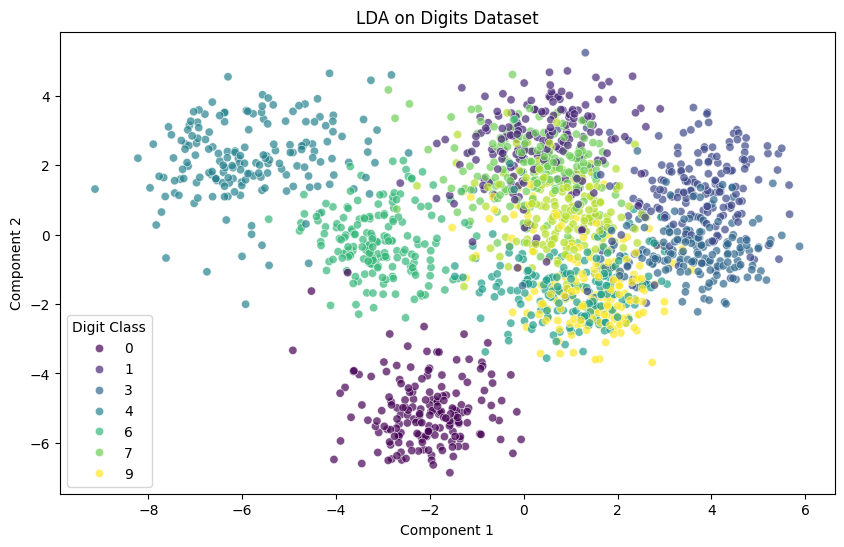

In [6]:
# Visualize
plt.figure(figsize=(10, 6))
sns.scatterplot(data=lda_df,
               x = 'Component 1', y = "Component 2", 
               hue = "target", palette = "viridis", alpha = 0.7)
plt.title("LDA on Digits Dataset")
plt.legend(title="Digit Class")
plt.show()